# Human Decision Making Under Uncertainty

Assignment conducted by: **Negi Hoxha(p3352524)**

---------------------------------------------------
Before we start with the tasks we installing and import the necessary libaries 

P.S: This assignment was written in VS Code. You may need to make a small change at this point: if you are running it in JupyterLab, replace ! with %.

In [21]:
!py -m pip install pandas numpy matplotlib scikit-learn

In [12]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


---------------------------------------------

## Data Loading and Merge (Selections + Problem Metadata)

In this step, I load both provided datasets and merge them into a single modeling table:

- **`c13k_selections.csv`** contains the row-level observations used for modeling (one row per selection).
- **`c13k_problems.json`** contains structured metadata for each problem (keyed by problem id), including information needed to interpret or derive features from the underlying decision structure. :contentReference[oaicite:0]{index=0}

### Merge strategy
Because the problem identifier column name can vary across datasets, I programmatically search for a plausible ID column in the selections table (e.g., `pid`, `problem_id`, `id`, etc.).  
Once identified:

1. I rename the ID column in `selections` to a consistent key: **`pid`**
2. I cast `pid` to string and strip whitespace in both datasets to prevent mismatched joins
3. I perform an **inner join** on `pid` to keep only problems that appear in both sources

### Validation checks
To ensure the merge worked correctly (and that the downstream pipeline has what it needs), I explicitly verify that the merged dataframe contains the required target column:

- `bRate` must exist after merging, otherwise the analysis stops early with a clear error message.

Finally, I preview the merged dataframe to confirm the structure looks correct.


In [13]:
sel = pd.read_csv("c13k_selections.csv")

with open("c13k_problems.json", "r", encoding="utf-8") as f:
    problems = json.load(f)

probs = pd.DataFrame.from_dict(problems, orient="index").reset_index()
probs = probs.rename(columns={"index": "pid"})

possible_id_cols = [
    "pid", "problem_id", "problem", "Problem", "ProblemID", "problemID",
    "problemId", "id", "ID"
]

sel_id = None
for c in possible_id_cols:
    if c in sel.columns:
        sel_id = c
        break

if sel_id is None:
    raise KeyError(
        "Could not find a problem-id column in c13k_selections.csv. "
        f"Columns found: {list(sel.columns)}"
    )

sel = sel.rename(columns={sel_id: "pid"})

sel["pid"] = sel["pid"].astype(str).str.strip()
probs["pid"] = probs["pid"].astype(str).str.strip()

df = sel.merge(probs, on="pid", how="inner")

if "bRate" not in df.columns:
    raise KeyError(
        "bRate column not found after merge. "
        "Check your CSV columns and merge keys."
    )


df.head()


,pid,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6, 14.0], [0.4, -18.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.95, 8.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.99, 28.0], [0.005, 31.0], [0.0025, 33.0], ...","[[1.0, 28.0], [0.0, 28.0]]"


-----------------------------------------------

## Feature Construction and Target Definition

The target variable for this analysis is:

- **`bRate`**: the frequency with which subjects selected **Gamble B** on a given problem.

This variable is cast to a floating-point value and serves as the regression target `y`.

---

## Base Features (Observed Problem Attributes)

The following base features are taken directly from the dataset and represent the structural properties of each decision problem:

- **`n`**: Number of subjects who faced the problem. Larger values imply more reliable estimates of `bRate`.
- **`Feedback`**: Indicates whether participants received outcome feedback, which can influence learning and risk-taking behavior.
- **`Block`**: Captures temporal or experimental block effects.
- **`Ha`, `La`, `pHa`**: Outcomes and probability defining Gamble A.
- **`Hb`, `Lb`, `pHb`**: Outcomes and probability defining Gamble B.
- **`LotNumB`**: Number of possible outcomes in Gamble B.
- **`LotShapeB`**: Encodes the skewness of the outcome distribution in Gamble B.
- **`Amb`**: Indicates whether probabilities for Gamble B were hidden (ambiguity).
- **`Corr`**: Captures correlation structure between payoffs of Gambles A and B.

These variables directly describe the economic structure and informational context of each choice problem.

---

## Derived Features (Decision-Theoretic Quantities)

To better capture how participants evaluate and compare gambles, I construct several derived features grounded in expected utility theory:

### Expected Value
- **`EV_A`**, **`EV_B`**: Expected value of each gamble, computed as a probability-weighted average of outcomes.

These features represent the central tendency of each option and are fundamental predictors of choice.

### Outcome Variance
- **`Var_A`**, **`Var_B`**: Variance of outcomes for each gamble.

Variance captures risk, allowing the model to distinguish between options with equal EV but different uncertainty.

### Comparative Features
To model *relative* evaluation between gambles, I compute difference-based features:

- **`dEV = EV_B − EV_A`**: Relative advantage of Gamble B in expected value.
- **`dVar = Var_B − Var_A`**: Relative risk difference between gambles.
- **`Range_A`, `Range_B`**: Outcome ranges for each gamble.
- **`dRange`**: Difference in outcome range between Gamble B and Gamble A.

These features reflect the fact that participants compare options rather than evaluate them in isolation.

---

## Feature Matrix Construction

All base and derived features are combined into the final design matrix `X`.  
To ensure compatibility with downstream machine learning models:

- All features are coerced to numeric types
- Rows with invalid numeric entries are handled implicitly via coercion
- Final feature and target shapes are validated before modeling

This results in a clean, fully numeric feature matrix suitable for regression models.


In [14]:
y = df["bRate"].astype(float)

df["EV_A"] = df["pHa"] * df["Ha"] + (1 - df["pHa"]) * df["La"]
df["EV_B"] = df["pHb"] * df["Hb"] + (1 - df["pHb"]) * df["Lb"]

df["Var_A"] = df["pHa"] * (df["Ha"] - df["EV_A"])**2 + (1 - df["pHa"]) * (df["La"] - df["EV_A"])**2
df["Var_B"] = df["pHb"] * (df["Hb"] - df["EV_B"])**2 + (1 - df["pHb"]) * (df["Lb"] - df["EV_B"])**2

df["dEV"]  = df["EV_B"] - df["EV_A"]
df["dVar"] = df["Var_B"] - df["Var_A"]

df["Range_A"] = df["Ha"] - df["La"]
df["Range_B"] = df["Hb"] - df["Lb"]
df["dRange"]  = df["Range_B"] - df["Range_A"]

base_cols = [
    "Feedback", "n", "Block",
    "Ha", "pHa", "La",
    "Hb", "pHb", "Lb",
    "LotShapeB", "LotNumB", "Amb", "Corr"
]

derived_cols = ["EV_A", "EV_B", "Var_A", "Var_B", "dEV", "dVar", "Range_A", "Range_B", "dRange"]

X = df[base_cols + derived_cols].copy()

X = X.apply(pd.to_numeric, errors="coerce")

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Any missing in X?", X.isna().any().any())
X.head()


X shape: (14568, 22)
y shape: (14568,)
Any missing in X? False


,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,...,Corr,EV_A,EV_B,Var_A,Var_B,dEV,dVar,Range_A,Range_B,dRange
0,True,15,2,26,0.95,-1,23,0.05,21,0,...,0,24.65,21.10,34.6275,0.1900,-3.55,-34.4375,27,2,-25
1,True,15,4,14,0.60,-18,8,0.25,-5,0,...,-1,1.20,-1.75,245.7600,31.6875,-2.95,-214.0725,32,13,-19
2,True,17,4,2,0.50,0,1,1.00,1,0,...,0,1.00,1.00,1.0000,0.0000,0.00,-1.0000,2,0,-2
3,True,18,3,37,0.05,8,87,0.25,-31,1,...,0,9.45,-1.50,39.9475,2610.7500,-10.95,2570.8025,29,118,89
4,False,15,1,26,1.00,26,45,0.75,-36,2,...,0,26.00,24.75,0.0000,1230.1875,-1.25,1230.1875,0,81,81


------------------------------------------------------------------------------------------
### Train–Test Split Rationale

An 80/20 train–test split is used to balance learning and evaluation.  
The training set (80%) provides sufficient data for model fitting and cross-validation, while the test set (20%) is kept fully unseen to obtain an unbiased estimate of generalization performance.

This split is a commonly used standard in machine learning and is well-suited to the size of this dataset.


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


cv = KFold(n_splits=5, shuffle=True, random_state=42)


---------------------------------------------------------------------
### Cross-Validated Model Evaluation

This function evaluates a given model using cross-validation and reports the required regression metrics:

- **MAE (primary metric)**  
- **RMSE**
- **R²**

Cross-validation ensures that performance estimates are robust and not dependent on a single train–test split.  
Negative error scores returned by scikit-learn are converted back to their positive values for interpretability.

The returned metrics represent the average performance across all cross-validation folds.



In [16]:
def evaluate_model(model, X, y, cv):
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2"
    }
    
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    
    return {
        "MAE": -scores["test_mae"].mean(),
        "RMSE": -scores["test_rmse"].mean(),
        "R2": scores["test_r2"].mean()
    }


--------------------------------------------------------------------------------
### Baseline Model: Linear Regression

A standard linear regression model is used as a baseline to evaluate how well simple linear relationships explain the choice behavior.

This model provides a reference point against which more complex models can be compared.  
Performance is evaluated using cross-validation and summarized using MAE (primary), RMSE, and R².


In [17]:
lr = LinearRegression()
lr_results = evaluate_model(lr, X, y, cv)

lr_results

{'MAE': np.float64(0.12717854255199787),
 'RMSE': np.float64(0.1568919229013682),
 'R2': np.float64(0.4994477497277591)}

---------------------------------------------------------------------------
### Decision Tree Regression and Depth Tuning

A decision tree regressor is evaluated to capture nonlinear relationships and feature interactions that linear models cannot represent.

The tree’s **maximum depth** is tuned using cross-validated MAE to control model complexity and prevent overfitting.  
Several depth values are tested, and the depth that minimizes MAE is selected.

The best-performing decision tree is then re-evaluated using cross-validation and summarized using MAE (primary), RMSE, and R².


In [18]:
depths = [3, 5, 10, 15, None]
dt_mae_scores = {}

for d in depths:
    model = DecisionTreeRegressor(max_depth=d, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
    dt_mae_scores[d] = -scores.mean()

best_depth = min(dt_mae_scores, key=dt_mae_scores.get)
print("Best max_depth:", best_depth)

best_dt = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_results = evaluate_model(best_dt, X, y, cv)



Best max_depth: 10


------------------------------------------------------------------------------------
### Random Forest Regression and Hyperparameter Tuning

A random forest regressor is evaluated to improve predictive performance by aggregating multiple decision trees and reducing variance.

Two key hyperparameters are tuned using cross-validated MAE:
- **Number of trees (`n_estimators`)**
- **Minimum samples per leaf (`min_samples_leaf`)**

These parameters control the bias–variance tradeoff of the ensemble.  
The parameter combination that minimizes MAE is selected, and the best-performing random forest model is then evaluated using cross-validation with MAE, RMSE, and R².


In [19]:
n_estimators_list = [50, 100, 200]
min_samples_leaf_list = [1, 5, 10]
rf_mae_scores = {}

for n in n_estimators_list:
    for leaf in min_samples_leaf_list:
        model = RandomForestRegressor(
            n_estimators=n,
            min_samples_leaf=leaf,
            random_state=42,
            n_jobs=-1
        )
        scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_absolute_error")
        rf_mae_scores[(n, leaf)] = -scores.mean()

best_rf_params = min(rf_mae_scores, key=rf_mae_scores.get)
print("Best RF params:", best_rf_params)

best_rf = RandomForestRegressor(
    n_estimators=best_rf_params[0],
    min_samples_leaf=best_rf_params[1],
    random_state=42,
    n_jobs=-1
)
rf_results = evaluate_model(best_rf, X, y, cv)


Best RF params: (200, 1)


KeyboardInterrupt: 

----------------------------------------------------------
### Model Performance Comparison

The table below compares the cross-validated performance of all evaluated models using the required metrics.

- **MAE** is the primary metric used for model selection
- **RMSE** provides additional insight into large prediction errors
- **R²** measures the proportion of variance explained by each model

The Random Forest model achieves the lowest MAE and the highest R², indicating superior predictive performance compared to both the decision tree and linear regression baselines.


In [ ]:
results = pd.DataFrame.from_dict(
    {
        "Linear Regression": lr_results,
        "Desicion Tree": dt_results,
        "RandomForest": rf_results
    },
    orient="index"
)

results.sort_values("MAE")


,MAE,RMSE,R2
RandomForest,0.082897,0.104719,0.776977
Desicion Tree,0.098463,0.127018,0.671804
Linear Regression,0.127179,0.156892,0.499448


-------------------------------------------------------
### Final Model Evaluation on Held-Out Test Set

The best-performing model (Random Forest) is trained on the full training set and evaluated on the held-out test set.

This evaluation provides an unbiased estimate of real-world performance using:
- **MAE** (primary metric)
- **RMSE**
- **R²**
  
These results confirm that the selected model generalizes well to unseen data.

In [ ]:
best_model = best_rf
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

final_mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)
final_rmse = np.sqrt(mse)

final_r2 = r2_score(y_test, y_pred)

final_mae, final_rmse, final_r2

(0.08141418754111852, np.float64(0.1039495472371595), 0.7792868855712959)

----------------------------------------------
### Feature Importance Analysis

To interpret the best-performing model, feature importances are extracted from the trained Random Forest.

The plot shows the relative contribution of each feature to the model’s predictions.  
Difference-based features, particularly **dEV** (difference in expected value between gambles), are the most influential, indicating that participants primarily compare options rather than evaluate them independently.

Risk-related features (e.g., outcome variance and ranges) and probability-weighted outcomes also contribute meaningfully, suggesting that both expected returns and uncertainty play a role in decision-making.


Overall, the feature importance results align with economic intuition and validate the feature engineering strategy.

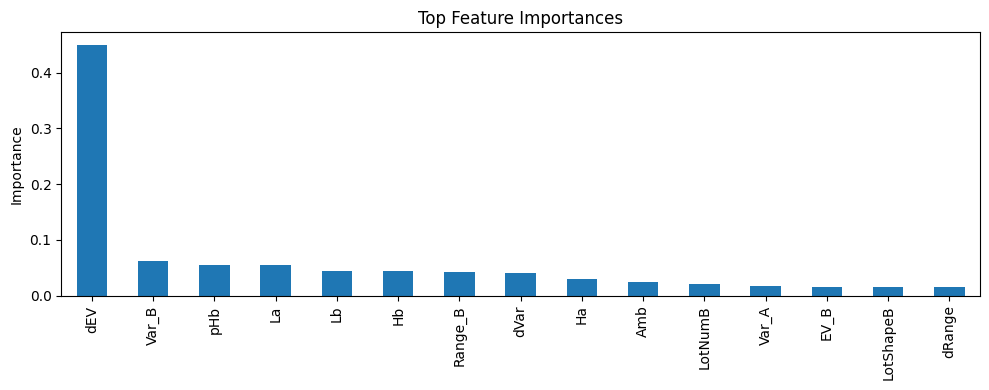

In [ ]:
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(15).plot(kind="bar", figsize=(10, 4), title="Top Feature Importances")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
